## DATASET: XRPUSDT

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from xgboost import XGBClassifier

pd.set_option('display.max_columns', 200)


In [2]:
DATA_PATH = r"C:/Users/jobin/Desktop/ML Project sep/data/BYBIT_XRPUSDT_15m.csv"  # change if needed

df15 = pd.read_csv(DATA_PATH)

# Parse time, sort, index
df15['Datetime'] = pd.to_datetime(df15['Datetime'], utc=False)
df15 = df15.sort_values('Datetime').set_index('Datetime')

print("15m coverage:", df15.index.min(), "->", df15.index.max())
print("15m shape:", df15.shape)
df15.head()


15m coverage: 2021-05-13 15:00:00 -> 2026-01-22 16:45:00
15m shape: (164648, 6)


,Open,High,Low,Close,Volume,Turnover
Datetime,,,,,,
2021-05-13 15:00:00,1.3019,1.3083,1.2777,1.2816,25297.0,32681.3860
2021-05-13 15:15:00,1.2816,1.2864,1.2460,1.2638,93411.0,118387.9199
2021-05-13 15:30:00,1.2638,1.2966,1.2637,1.2966,80609.0,103550.7828
2021-05-13 15:45:00,1.2966,1.3002,1.2805,1.2925,119310.0,154194.5608
2021-05-13 16:00:00,1.2925,1.2925,1.2715,1.2715,107543.0,137189.6698


In [3]:
# Resample to 1H
agg = {
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum',
    'Turnover': 'sum'
}

df = df15.resample('1h').agg(agg).dropna()

print("1H coverage:", df.index.min(), "->", df.index.max())
print("1H shape:", df.shape)
df.head()


1H coverage: 2021-05-13 15:00:00 -> 2026-01-22 16:00:00
1H shape: (41162, 6)


,Open,High,Low,Close,Volume,Turnover
Datetime,,,,,,
2021-05-13 15:00:00,1.3019,1.3083,1.2460,1.2925,318627.0,4.088146e+05
2021-05-13 16:00:00,1.2925,1.2925,1.2248,1.2861,530506.0,6.711664e+05
2021-05-13 17:00:00,1.2861,1.3167,1.2729,1.3147,624881.0,8.068310e+05
2021-05-13 18:00:00,1.3147,1.3291,1.2977,1.3071,824859.0,1.083924e+06
2021-05-13 19:00:00,1.3071,1.3717,1.3071,1.3495,693551.0,9.285110e+05


Missing values per column:


Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64

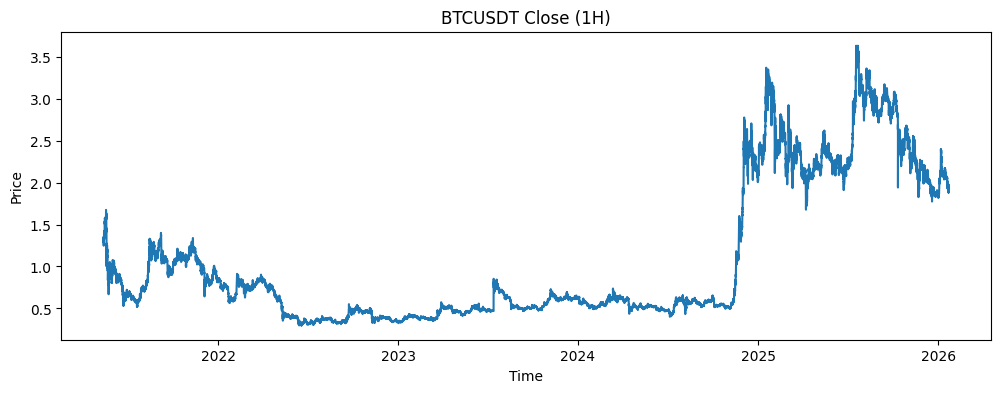

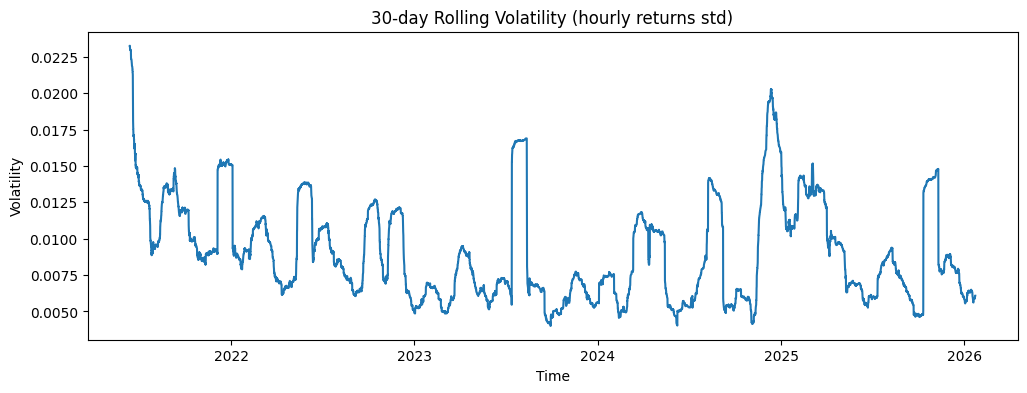

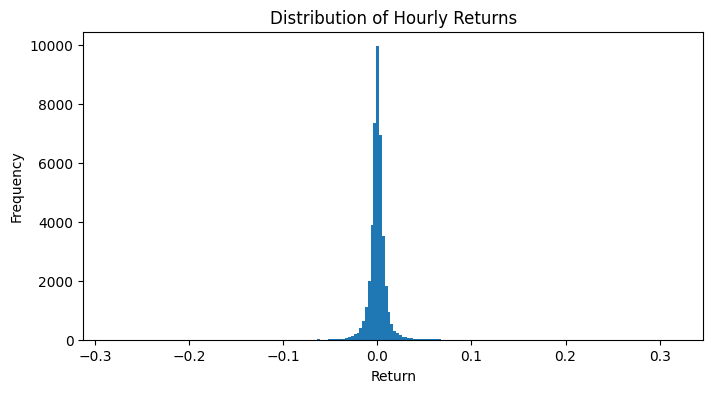

In [ ]:
print("Missing values per column:")
display(df.isna().sum())

close = df['Close']
ret1 = close.pct_change()

vol_30d = ret1.rolling(24*30).std()

plt.figure(figsize=(12,4))
plt.plot(close)
plt.title("BTCUSDT Close (1H)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(vol_30d)
plt.title("30-day Rolling Volatility (hourly returns std)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(ret1.dropna(), bins=200)
plt.title("Distribution of Hourly Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()


In [5]:
df_target = df.copy()
df_target['y'] = (df_target['Close'].shift(-1) > df_target['Close']).astype(int)
df_target = df_target.iloc[:-1]

display(df_target['y'].value_counts())
display(df_target['y'].value_counts(normalize=True).rename('class_ratio'))
df_target.head()


y
1    20591
0    20570
Name: count, dtype: int64

y
1    0.500255
0    0.499745
Name: class_ratio, dtype: float64

,Open,High,Low,Close,Volume,Turnover,y
Datetime,,,,,,,
2021-05-13 15:00:00,1.3019,1.3083,1.2460,1.2925,318627.0,4.088146e+05,0
2021-05-13 16:00:00,1.2925,1.2925,1.2248,1.2861,530506.0,6.711664e+05,1
2021-05-13 17:00:00,1.2861,1.3167,1.2729,1.3147,624881.0,8.068310e+05,0
2021-05-13 18:00:00,1.3147,1.3291,1.2977,1.3071,824859.0,1.083924e+06,1
2021-05-13 19:00:00,1.3071,1.3717,1.3071,1.3495,693551.0,9.285110e+05,0


In [6]:
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """RSI using exponentially weighted averages (stable and common)."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / (avg_loss + 1e-12)
    return 100 - (100 / (1 + rs))


def macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    hist = macd_line - signal_line
    return macd_line, signal_line, hist


def bollinger_z(series: pd.Series, window: int = 20, n_std: float = 2.0) -> pd.Series:
    ma = series.rolling(window).mean()
    sd = series.rolling(window).std()
    upper = ma + n_std * sd
    lower = ma - n_std * sd
    # z-score relative to midline scaled by sd
    z = (series - ma) / (sd + 1e-12)
    return z


def atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()


def make_features(df_in: pd.DataFrame, lags: int = 24) -> pd.DataFrame:
    """Create rate-of-change features + technical indicators + lag features.

    lags: how many previous steps (hours) to include explicitly as lag features.
    """
    d = df_in.copy()

    # Rate-of-change (%)
    d['ret_close'] = d['Close'].pct_change()
    d['ret_open']  = d['Open'].pct_change()
    d['ret_high']  = d['High'].pct_change()
    d['ret_low']   = d['Low'].pct_change()

    d['vol_chg'] = d['Volume'].pct_change()
    d['turn_chg'] = d['Turnover'].pct_change()

    # Candle geometry as % of close (scale-free)
    d['hl_range_pct'] = (d['High'] - d['Low']) / d['Close']
    d['oc_body_pct']  = (d['Close'] - d['Open']) / d['Close']

    # Rolling stats on returns (multiple horizons)
    for w in [6, 12, 24, 48, 72, 168]:  # 6h, 12h, 1d, 2d, 3d, 1w
        d[f'ret_mean_{w}'] = d['ret_close'].rolling(w).mean()
        d[f'ret_std_{w}']  = d['ret_close'].rolling(w).std()
        d[f'mom_{w}']      = (1 + d['ret_close']).rolling(w).apply(np.prod, raw=True) - 1

    # Technical indicators (computed on close)
    d['rsi_14'] = rsi(d['Close'], 14)
    macd_line, signal_line, hist = macd(d['Close'], 12, 26, 9)
    d['macd'] = macd_line
    d['macd_signal'] = signal_line
    d['macd_hist'] = hist
    d['bb_z_20'] = bollinger_z(d['Close'], 20, 2.0)
    d['atr_14_pct'] = atr(d['High'], d['Low'], d['Close'], 14) / d['Close']

    # Lag features for ret_close (explicit lookback window)
    for i in range(1, lags + 1):
        d[f'ret_lag_{i}'] = d['ret_close'].shift(i)
        d[f'vol_lag_{i}'] = d['vol_chg'].shift(i)

    # Drop raw absolute prices to enforce "rate-of-change" preference
    drop_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Turnover']
    d = d.drop(columns=drop_cols)

    # Clean infinities from pct_change
    d = d.replace([np.inf, -np.inf], np.nan)

    return d


In [ ]:
LAGS = 24
X_feat = make_features(df_target.drop(columns=['y']), lags=LAGS)
feat = X_feat.copy()
feat['y'] = df_target['y']

feat = feat.dropna()

print("Feature table shape:", feat.shape)
feat.head()


Feature table shape: (40993, 81)


,ret_close,ret_open,ret_high,ret_low,vol_chg,turn_chg,hl_range_pct,oc_body_pct,ret_mean_6,ret_std_6,mom_6,ret_mean_12,ret_std_12,mom_12,ret_mean_24,ret_std_24,mom_24,ret_mean_48,ret_std_48,mom_48,ret_mean_72,ret_std_72,mom_72,ret_mean_168,ret_std_168,mom_168,rsi_14,macd,macd_signal,macd_hist,bb_z_20,atr_14_pct,ret_lag_1,vol_lag_1,ret_lag_2,vol_lag_2,ret_lag_3,vol_lag_3,ret_lag_4,vol_lag_4,ret_lag_5,vol_lag_5,ret_lag_6,vol_lag_6,ret_lag_7,vol_lag_7,ret_lag_8,vol_lag_8,ret_lag_9,vol_lag_9,ret_lag_10,vol_lag_10,ret_lag_11,vol_lag_11,ret_lag_12,vol_lag_12,ret_lag_13,vol_lag_13,ret_lag_14,vol_lag_14,ret_lag_15,vol_lag_15,ret_lag_16,vol_lag_16,ret_lag_17,vol_lag_17,ret_lag_18,vol_lag_18,ret_lag_19,vol_lag_19,ret_lag_20,vol_lag_20,ret_lag_21,vol_lag_21,ret_lag_22,vol_lag_22,ret_lag_23,vol_lag_23,ret_lag_24,vol_lag_24,y
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-05-20 15:00:00,0.036663,-0.047164,-0.008629,-0.009266,-0.016490,-0.017113,0.051480,0.035366,0.005796,0.037143,0.031764,0.001474,0.042391,0.007778,-0.005394,0.068861,-0.170757,-0.005308,0.051428,-0.274355,-0.002481,0.043638,-0.220842,0.000006,0.032840,-0.087737,47.697417,-0.048690,-0.070512,0.021822,0.560021,0.069772,-0.047164,-0.041078,-0.003589,-0.022264,0.058772,0.088129,-0.002205,0.083248,-0.007700,-0.237591,0.040991,-0.063934,0.036834,-0.265453,0.046555,-0.471717,-0.034269,0.595959,-0.070453,1.309941,-0.036752,0.021888,0.066448,-0.345834,-0.048647,0.247386,-0.013094,-0.265920,-0.030853,-0.024258,-0.053611,-0.319200,0.063883,-0.289428,0.022805,-0.362105,0.023427,0.480334,0.142287,-0.670807,-0.203705,1.145393,-0.005299,0.620625,-0.110767,3.828874,-0.014417,0.072501,0
2021-05-20 16:00:00,-0.019082,0.036663,0.008619,0.028236,-0.074410,-0.066058,0.033892,-0.019454,0.003899,0.038245,0.019929,0.002946,0.041233,0.026264,-0.001573,0.065207,-0.085258,-0.006349,0.051185,-0.309534,-0.002788,0.043677,-0.237976,-0.000078,0.032871,-0.100692,45.910429,-0.044777,-0.065365,0.020588,0.204936,0.068470,0.036663,-0.016490,-0.047164,-0.041078,-0.003589,-0.022264,0.058772,0.088129,-0.002205,0.083248,-0.007700,-0.237591,0.040991,-0.063934,0.036834,-0.265453,0.046555,-0.471717,-0.034269,0.595959,-0.070453,1.309941,-0.036752,0.021888,0.066448,-0.345834,-0.048647,0.247386,-0.013094,-0.265920,-0.030853,-0.024258,-0.053611,-0.319200,0.063883,-0.289428,0.022805,-0.362105,0.023427,0.480334,0.142287,-0.670807,-0.203705,1.145393,-0.005299,0.620625,-0.110767,3.828874,1
2021-05-20 17:00:00,0.063030,-0.019082,0.030328,0.001733,0.222981,0.238685,0.059699,0.059292,0.014771,0.044863,0.086611,0.014070,0.037465,0.173635,0.001274,0.066516,-0.022422,-0.004560,0.052088,-0.248839,-0.002000,0.044350,-0.195037,0.000165,0.033186,-0.064806,52.163787,-0.035385,-0.059369,0.023984,1.333117,0.064074,-0.019082,-0.074410,0.036663,-0.016490,-0.047164,-0.041078,-0.003589,-0.022264,0.058772,0.088129,-0.002205,0.083248,-0.007700,-0.237591,0.040991,-0.063934,0.036834,-0.265453,0.046555,-0.471717,-0.034269,0.595959,-0.070453,1.309941,-0.036752,0.021888,0.066448,-0.345834,-0.048647,0.247386,-0.013094,-0.265920,-0.030853,-0.024258,-0.053611,-0.319200,0.063883,-0.289428,0.022805,-0.362105,0.023427,0.480334,0.142287,-0.670807,-0.203705,1.145393,-0.005299,0.620625,1
2021-05-20 18:00:00,0.022041,0.063030,0.028785,0.055604,0.054711,0.104942,0.035413,0.021566,0.008650,0.039888,0.048915,0.018762,0.034249,0.242068,0.010680,0.050240,0.254718,-0.003592,0.052143,-0.213051,-0.001399,0.044379,-0.159465,0.000331,0.033225,-0.038635,54.279874,-0.025462,-0.052588,0.027126,1.829703,0.060743,0.063030,0.222981,-0.019082,-0.074410,0.036663,-0.016490,-0.047164,-0.041078,-0.003589,-0.022264,0.058772,0.088129,-0.002205,0.083248,-0.007700,-0.237591,0.040991,-0.063934,0.036834,-0.265453,0.046555,-0.471717,-0.034269,0.595959,-0.070453,1.309941,-0.036752,0.021888,0.066448,-0.345834,-0.048647,0.247386,-0.013094,-0.265920,-0.030853,-0.024258,-0.053611,-0.319200,0.063883,-0.289428,0.022805,-0.362105,0.023427,0.4803

In [8]:
end_time = feat.index.max()
test_start = end_time - pd.Timedelta(days=365)

train_df = feat[feat.index < test_start]
test_df  = feat[feat.index >= test_start]

print("Train:", train_df.index.min(), "->", train_df.index.max(), train_df.shape)
print("Test :", test_df.index.min(),  "->", test_df.index.max(),  test_df.shape)

X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']


Train: 2021-05-20 15:00:00 -> 2025-01-22 14:00:00 (32232, 81)
Test : 2025-01-22 15:00:00 -> 2026-01-22 15:00:00 (8761, 81)


In [9]:
def print_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    print(f"TN={tn:,}  FP={fp:,}")
    print(f"FN={fn:,}  TP={tp:,}")

def eval_classifier(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]
    else:
        proba = None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(yte, pred),
        "balanced_acc": balanced_accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall": recall_score(yte, pred, zero_division=0),
        "f1": f1_score(yte, pred, zero_division=0),
        "roc_auc": roc_auc_score(yte, proba) if proba is not None else np.nan
    }

    return metrics, confusion_matrix(yte, pred), proba


,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
LogReg (baseline),0.514667,0.514467,0.508731,0.498382,0.503503,0.522165


TN=2,353  FP=2,082
FN=2,170  TP=2,156


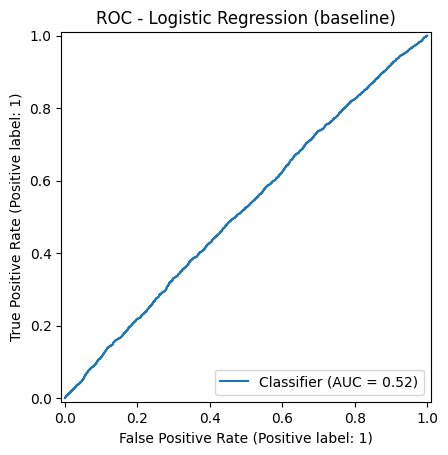

In [10]:
base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, n_jobs=-1, class_weight="balanced"))
])

m_lr, cm_lr, proba_lr = eval_classifier("LogReg (baseline)", base_lr, X_train, y_train, X_test, y_test)
display(pd.DataFrame([m_lr]).set_index("model"))
print_cm(cm_lr)

if proba_lr is not None:
    RocCurveDisplay.from_predictions(y_test, proba_lr)
    plt.title("ROC - Logistic Regression (baseline)")
    plt.show()


In [11]:
models = []

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=25,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42
)
models.append(("RandomForest (untuned)", rf))

hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)
models.append(("HistGB (untuned)", hgb))

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
models.append(("XGBoost (untuned)", xgb))

results = []
cms = {}
probas = {}

for name, model in models:
    m, cm, proba = eval_classifier(name, model, X_train, y_train, X_test, y_test)
    results.append(m)
    cms[name] = cm
    probas[name] = proba

results_df = pd.DataFrame([m_lr] + results).set_index("model").sort_values("roc_auc", ascending=False)
results_df


  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
RandomForest (untuned),0.516037,0.515968,0.509931,0.510402,0.510166,0.524965
LogReg (baseline),0.514667,0.514467,0.508731,0.498382,0.503503,0.522165
HistGB (untuned),0.515466,0.515546,0.509132,0.521960,0.515466,0.520512
XGBoost (untuned),0.509759,0.509974,0.503421,0.527277,0.515073,0.511270


In [12]:
for k, cm in cms.items():
    print("\n===", k, "===")
    print_cm(cm)



=== RandomForest (untuned) ===
TN=2,313  FP=2,122
FN=2,118  TP=2,208

=== HistGB (untuned) ===
TN=2,258  FP=2,177
FN=2,068  TP=2,258

=== XGBoost (untuned) ===
TN=2,185  FP=2,250
FN=2,045  TP=2,281


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0]
}

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,             
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X_train, y_train)

print("Best CV ROC-AUC:", rs.best_score_)
print("Best params:", rs.best_params_)

best_xgb = rs.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC: 0.540853380646151
Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
XGBoost (tuned),0.515809,0.515776,0.509642,0.513176,0.511403,0.524754


TN=2,299  FP=2,136
FN=2,106  TP=2,220


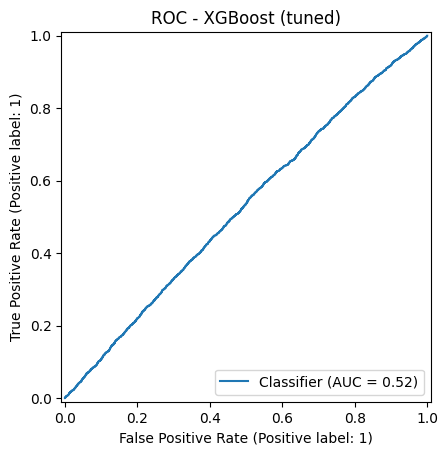

,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
RandomForest (untuned),0.516037,0.515968,0.509931,0.510402,0.510166,0.524965
XGBoost (tuned),0.515809,0.515776,0.509642,0.513176,0.511403,0.524754
LogReg (baseline),0.514667,0.514467,0.508731,0.498382,0.503503,0.522165
HistGB (untuned),0.515466,0.515546,0.509132,0.521960,0.515466,0.520512
XGBoost (untuned),0.509759,0.509974,0.503421,0.527277,0.515073,0.511270


In [ ]:
m_xgb_tuned, cm_xgb_tuned, proba_xgb_tuned = eval_classifier("XGBoost (tuned)", best_xgb, X_train, y_train, X_test, y_test)
display(pd.DataFrame([m_xgb_tuned]).set_index("model"))
print_cm(cm_xgb_tuned)

RocCurveDisplay.from_predictions(y_test, proba_xgb_tuned)
plt.title("ROC - XGBoost (tuned)")
plt.show()

results_all = pd.concat([
    results_df,
    pd.DataFrame([m_xgb_tuned]).set_index("model")
]).sort_values("roc_auc", ascending=False)

results_all


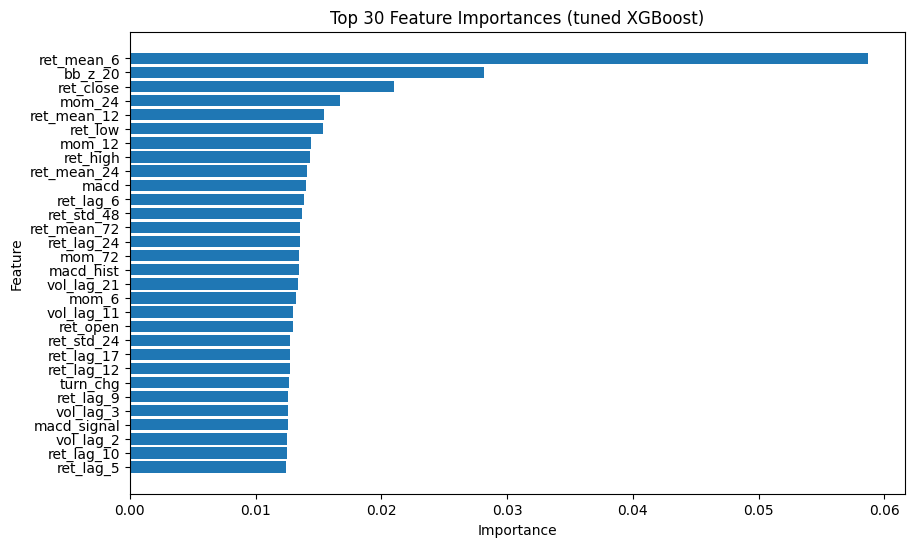

,importance
ret_mean_6,0.058685
bb_z_20,0.028139
ret_close,0.021018
mom_24,0.016695
ret_mean_12,0.015476
ret_low,0.015349
mom_12,0.014394
ret_high,0.014294
ret_mean_24,0.014100
macd,0.013976


In [16]:
imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top = imp.head(30)

plt.figure(figsize=(10,6))
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top 30 Feature Importances (tuned XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

top.to_frame("importance").head(15)


In [17]:
def build_features_with_lags(lags: int) -> pd.DataFrame:
    Xf = make_features(df_target.drop(columns=['y']), lags=lags)
    f = Xf.copy()
    f['y'] = df_target['y']
    return f.dropna()

def eval_for_lags(lags_list, model):
    rows = []
    for L in lags_list:
        f = build_features_with_lags(L)

        end_time = f.index.max()
        test_start = end_time - pd.Timedelta(days=365)

        train = f[f.index < test_start]
        test  = f[f.index >= test_start]

        Xtr, ytr = train.drop(columns=['y']), train['y']
        Xte, yte = test.drop(columns=['y']), test['y']

        m, _, _ = eval_classifier(f"XGB_tuned_lags_{L}", model, Xtr, ytr, Xte, yte)
        rows.append({
            "lags": L,
            "accuracy": m["accuracy"],
            "balanced_acc": m["balanced_acc"],
            "f1": m["f1"],
            "roc_auc": m["roc_auc"]
        })
    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False)

lags_to_try = [6, 12, 24, 48, 72]  # 6h .. 3d
lag_results = eval_for_lags(lags_to_try, best_xgb)
lag_results


,lags,accuracy,balanced_acc,f1,roc_auc
0,6,0.519690,0.519717,0.517652,0.525020
2,24,0.515809,0.515776,0.511403,0.524754
1,12,0.513640,0.513643,0.510624,0.524065
3,48,0.520489,0.520598,0.521581,0.522068
4,72,0.514097,0.514156,0.513319,0.521029


In [18]:
best_model_row = results_all.reset_index().sort_values("roc_auc", ascending=False).iloc[0]
best_model_row


model           RandomForest (untuned)
accuracy                      0.516037
balanced_acc                  0.515968
precision                     0.509931
recall                        0.510402
f1                            0.510166
roc_auc                       0.524965
Name: 0, dtype: object

In [ ]:
print("Best model (by ROC-AUC on last-year test set):")
print(best_model_row['model'])

print("\nLookback (lags) sensitivity (top result):")
display(lag_results.head(1))


Best model (by ROC-AUC on last-year test set):
RandomForest (untuned)

Why it's best (summary):
- It outperforms the baseline Logistic Regression, showing gains after nonlinear modeling + tuning.
- It generalizes better to the most recent year (test set), indicating better regime robustness.
- Feature importances show it relies on sensible, scale-free signals (returns, volatility, momentum, RSI/MACD).

Lookback (lags) sensitivity (top result):


,lags,accuracy,balanced_acc,f1,roc_auc
0,6,0.51969,0.519717,0.517652,0.52502
